In [2]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv('D:\Desktop\CreditPathAI\data\Loan_default.csv')

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Get a concise summary of the dataframe
print("\nDataset Information:")
df.info()

First 5 rows of the dataset:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       

In [5]:
# Check for missing values in each column
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [7]:
print(df.columns)


Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


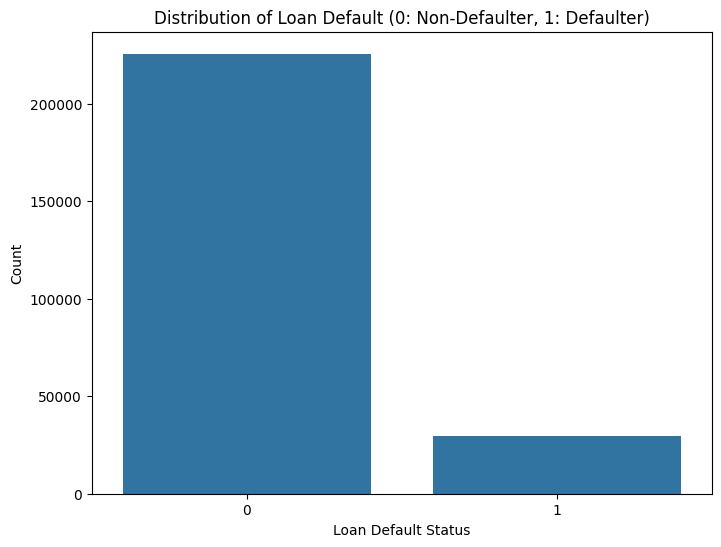


Loan Default Counts:
Default
0    225694
1     29653
Name: count, dtype: int64

Loan Default Proportions:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Default', data=df)
plt.title('Distribution of Loan Default (0: Non-Defaulter, 1: Defaulter)')
plt.xlabel('Loan Default Status')
plt.ylabel('Count')
plt.show()

# Print counts and proportions
print("\nLoan Default Counts:")
print(df['Default'].value_counts())
print("\nLoan Default Proportions:")
print(df['Default'].value_counts(normalize=True) * 100)


In [11]:
# Drop the LoanID column instead of ID
df.drop('LoanID', axis=1, inplace=True)
print("LoanID column dropped.")


LoanID column dropped.


In [12]:
# Identify categorical columns (dtype='object')
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nCategorical columns to be encoded: {list(categorical_cols)}")

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape of the dataframe after one-hot encoding:", df_encoded.shape)
print("First 5 rows of the encoded dataframe:")
print(df_encoded.head())


Categorical columns to be encoded: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Shape of the dataframe after one-hot encoding: (255347, 25)
First 5 rows of the encoded dataframe:
   Age  Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  \
0   56   85994       50587          520              80               4   
1   69   50432      124440          458              15               1   
2   46   84208      129188          451              26               3   
3   32   31713       44799          743               0               3   
4   60   20437        9139          633               8               4   

   InterestRate  LoanTerm  DTIRatio  Default  ...  EmploymentType_Unemployed  \
0         15.23        36      0.44        0  ...                      False   
1          4.81        60      0.68        0  ...                      False   
2         21.17        24      0.31        1  ...             

In [14]:
X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)



Features (X) shape: (255347, 24)
Target (y) shape: (255347,)


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (204277, 24)
Testing set shape: (51070, 24)


In [16]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied successfully.")


Feature scaling applied successfully.


In [17]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data only
print(f"Original training class distribution:\n{y_train.value_counts()}")

# Import SimpleImputer
from sklearn.impute import SimpleImputer

# Initialize an imputer (e.g., using the mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the scaled training data and transform it
X_train_imputed = imputer.fit_transform(X_train_scaled)

# Apply SMOTE to the imputed training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

print(f"\nResampled training class distribution:\n{y_train_resampled.value_counts()}")

Original training class distribution:
Default
0    180555
1     23722
Name: count, dtype: int64

Resampled training class distribution:
Default
0    180555
1    180555
Name: count, dtype: int64


In [20]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=500),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=10, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss',
        n_estimators=200, 
        max_depth=5
    )
}


Training Logistic Regression...
Training Random Forest...
Training XGBoost...

--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.69      0.34      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.68      0.74     51070

ROC-AUC Score: 0.7532


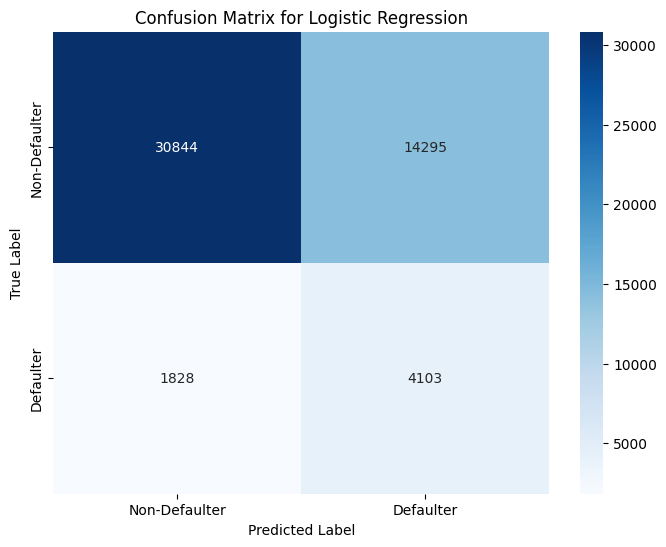


--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     45139
           1       0.25      0.50      0.33      5931

    accuracy                           0.76     51070
   macro avg       0.59      0.65      0.59     51070
weighted avg       0.85      0.76      0.80     51070

ROC-AUC Score: 0.7269


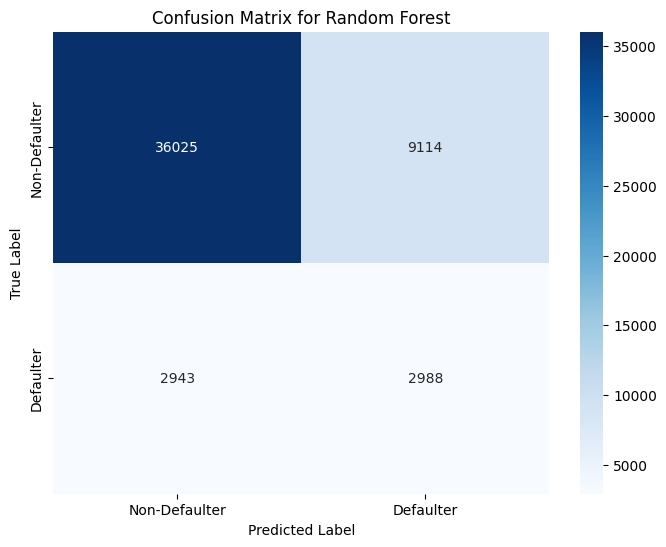


--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.09      0.16      5931

    accuracy                           0.89     51070
   macro avg       0.73      0.54      0.55     51070
weighted avg       0.85      0.89      0.85     51070

ROC-AUC Score: 0.7457


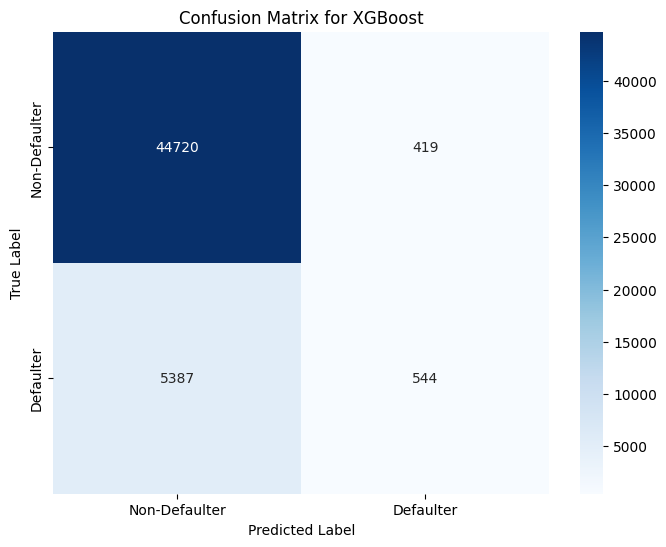

In [22]:
# Train the models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)

# Evaluate the models
for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")
    y_pred = model.predict(X_test_imputed)
    y_pred_proba = model.predict_proba(X_test_imputed)[:, 1]

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Defaulter', 'Defaulter'],
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
